# AAPL Next-Day Direction: Traditional ML

Run top to bottom. This notebook uses chronological partitions and keeps the test period out of model selection.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import yfinance as yf
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
from pyod.models.ecod import ECOD
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix,
                             f1_score, precision_score, recall_score, roc_auc_score)
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

ROOT = Path.cwd()
if not (ROOT / 'src').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
from src.features import FEATURES, make_features

pd.set_option('display.max_columns', 30)
sns.set_theme(style='whitegrid')

Fontconfig error: No writable cache directories


Matplotlib is building the font cache; this may take a moment.


## 1. Download and inspect data

The end date is exclusive in yfinance. Keep the raw download local; do not commit it.

In [2]:
ticker = 'AAPL'
start_date, end_date = '2015-01-01', '2026-01-01'
csv_path = ROOT / 'data/raw/aapl_ohlcv.csv'
if csv_path.exists():
    raw = pd.read_csv(csv_path, index_col=0, parse_dates=True)
else:
    raw = yf.download(ticker, start=start_date, end=end_date, auto_adjust=True, progress=False)
    if raw.empty:
        raise RuntimeError('No data returned. Check internet access and ticker symbol.')
    if isinstance(raw.columns, pd.MultiIndex):
        raw.columns = raw.columns.get_level_values(0)
    raw = raw[['Open', 'High', 'Low', 'Close', 'Volume']].dropna()
    raw.index = pd.to_datetime(raw.index)
    raw.to_csv(csv_path)
print(f'{len(raw):,} rows | {raw.index.min().date()} to {raw.index.max().date()}')
print('Missing values:', int(raw.isna().sum().sum()))
display(raw.head())

2,766 rows | 2015-01-02 to 2025-12-31
Missing values: 0


,Open,High,Low,Close,Volume
Date,,,,,
2015-01-02,24.627194,24.638249,23.733991,24.171749,212818400
2015-01-05,23.941821,24.021413,23.305082,23.490797,257142000
2015-01-06,23.554914,23.751684,23.132632,23.493010,263188400
2015-01-07,23.700841,23.921931,23.590296,23.822441,160423600
2015-01-08,24.149655,24.795237,24.032475,24.737753,237458000


## 2. Explore the series

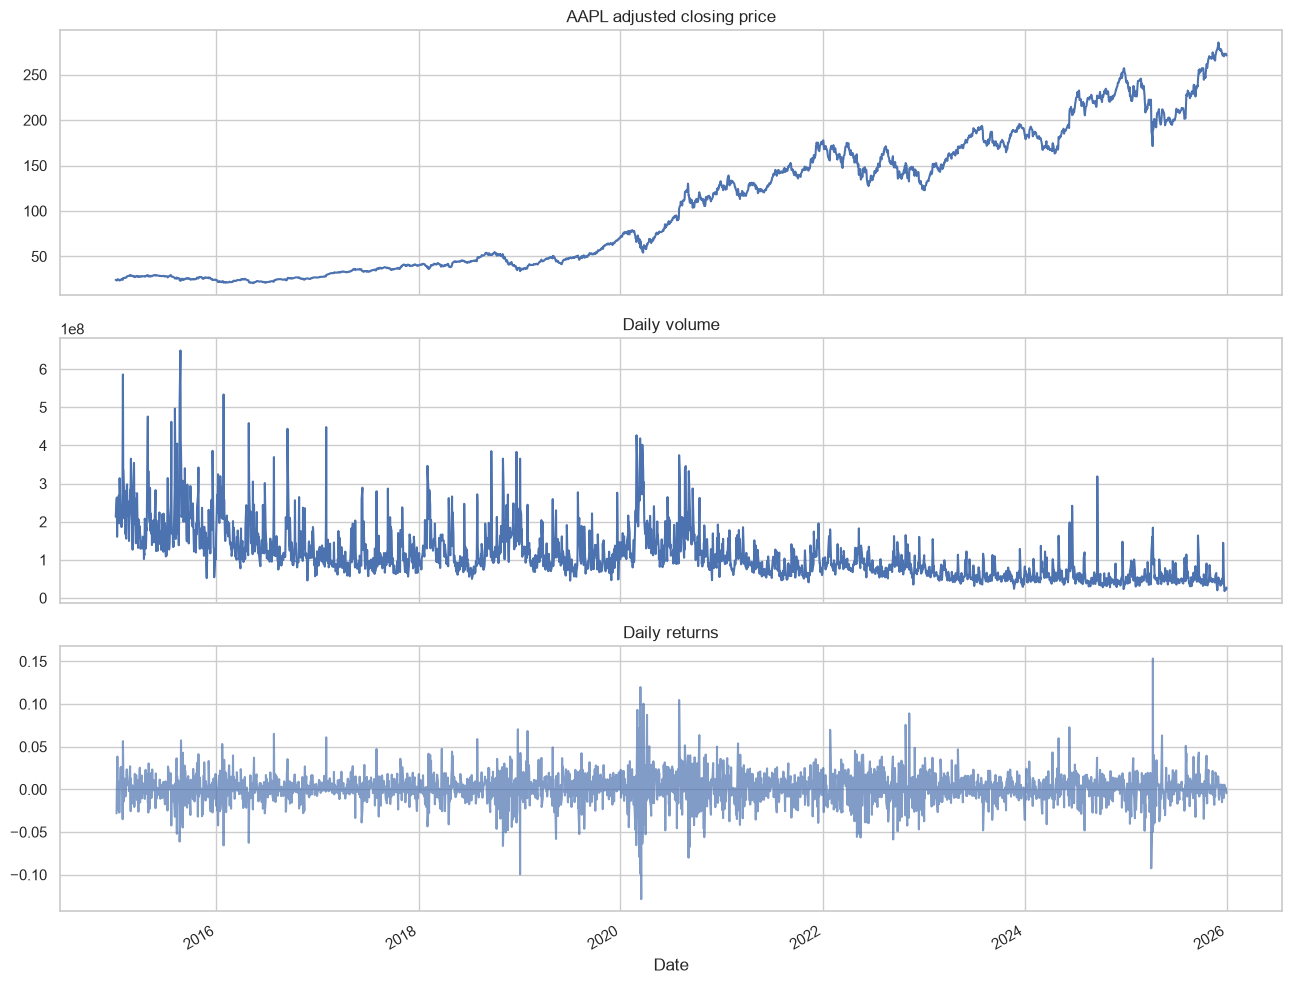

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)
raw['Close'].plot(ax=axes[0], title='AAPL adjusted closing price')
raw['Volume'].plot(ax=axes[1], title='Daily volume')
raw['Close'].pct_change().plot(ax=axes[2], title='Daily returns', alpha=.7)
plt.tight_layout()

count    2765.000000
mean        0.001039
std         0.018171
min        -0.128647
25%        -0.007282
50%         0.000951
75%         0.010014
max         0.153289
Name: Close, dtype: float64


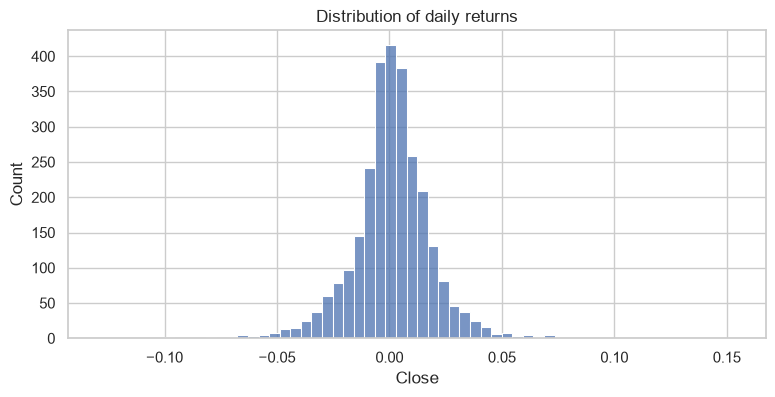

In [4]:
returns = raw['Close'].pct_change().dropna()
print(returns.describe())
fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(returns, bins=60, ax=ax)
ax.set_title('Distribution of daily returns')
plt.show()

## 2.1 Statistical time-series diagnostics (Statsmodels)

The Augmented Dickey–Fuller test checks for a unit root in price levels and returns. The Ljung–Box test checks whether daily returns show serial autocorrelation at selected lags. These diagnostics describe the series; they do not establish that returns are forecastable.

In [5]:
price_adf = adfuller(raw['Close'], autolag='AIC')
return_adf = adfuller(returns, autolag='AIC')
print(f'ADF price level: statistic={price_adf[0]:.3f}, p-value={price_adf[1]:.4g}')
print(f'ADF daily returns: statistic={return_adf[0]:.3f}, p-value={return_adf[1]:.4g}')
display(acorr_ljungbox(returns, lags=[5, 10], return_df=True))

ADF price level: statistic=0.659, p-value=0.989
ADF daily returns: statistic=-16.645, p-value=1.624e-29


/var/folders/4r/zkkn0kss3xb0rxxh824szfcr0000gn/T/ipykernel_72751/1835857287.py:1: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  price_adf = adfuller(raw['Close'], autolag='AIC')
/var/folders/4r/zkkn0kss3xb0rxxh824szfcr0000gn/T/ipykernel_72751/1835857287.py:2: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  return_adf = adfuller(returns, autolag='AIC')


,lb_stat,lb_pvalue
5,13.126481,2.222190e-02
10,65.186703,3.733245e-10


## 3. Build causal features and inspect the target

The target is 1 when the next session's close is above its open, matching the strategy's tradable open-to-close return. Features use AAPL OHLCV information through today's close.

(2716, 17)
Positive class share: 0.536


,return_1d,return_2d,return_5d,price_vs_ma5,price_vs_ma20,price_vs_ma50,volatility_5,volatility_20,volume_change,volume_vs_ma20,high_low_range,target
Date,,,,,,,,,,,,
2015-03-16,0.011004,0.004018,-0.017225,0.008084,-0.021619,0.045989,0.017320,0.013712,-0.307811,-0.387757,0.016647,1
2015-03-17,0.016727,0.027915,0.020320,0.020779,-0.004946,0.060265,0.015988,0.014193,0.422274,-0.120116,0.013145,1
2015-03-18,0.011256,0.028171,0.050965,0.022037,0.006353,0.068163,0.009988,0.014339,0.279242,0.106148,0.021717,0
2015-03-19,-0.007550,0.003621,0.024508,0.009421,-0.000874,0.056294,0.011314,0.014433,-0.298164,-0.229182,0.014510,0
2015-03-20,-0.012549,-0.020004,0.018691,-0.006878,-0.012018,0.039838,0.012949,0.014538,0.499582,0.137014,0.025735,1


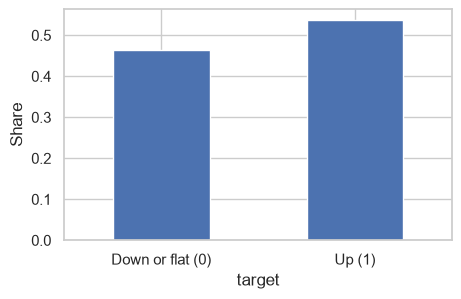

In [6]:
data = make_features(raw)
print(data.shape)
print('Positive class share:', round(data['target'].mean(), 3))
display(data[FEATURES + ['target']].head())
fig, ax = plt.subplots(figsize=(5, 3))
data['target'].value_counts(normalize=True).sort_index().plot.bar(ax=ax)
ax.set_xticklabels(['Down or flat (0)', 'Up (1)'], rotation=0)
ax.set_ylabel('Share')
plt.show()

## 4. Chronological split

Training ends before 2023, validation covers 2023–2024, and test covers 2025. Validation can guide model choices; do not tune against the final test period.

In [7]:
train = data.loc[data.index < '2023-01-01']
valid = data.loc[(data.index >= '2023-01-01') & (data.index < '2025-01-01')]
test = data.loc[(data.index >= '2025-01-01') & (data.index < '2026-01-01')]
# Purge the final train and validation signals: their next-session labels
# would otherwise cross into the following split.
train, valid = train.iloc[:-1], valid.iloc[:-1]
for name, part in [('train', train), ('validation', valid), ('test', test)]:
    print(name, part.index.min().date(), part.index.max().date(), len(part))
X_train, y_train = train[FEATURES], train['target'].astype(int)
X_valid, y_valid = valid[FEATURES], valid['target'].astype(int)
X_test, y_test = test[FEATURES], test['target'].astype(int)

train 2015-03-16 2022-12-29 1964
validation 2023-01-03 2024-12-30 501
test 2025-01-02 2025-12-30 249


## 5.1 Unusual-market-day detection (PyOD)

ECOD is fit only on training features. The training data sets the anomaly threshold; validation and test rows are scored against it. Anomaly flags are descriptive and are not used as labels or fed into the classifier.

Flagged 8 of 249 test observations as unusual.
Only 8 days were flagged; treat their next-day outcomes as descriptive, not conclusive.
Next-session open-to-close up share among flagged observations: 0.625


,anomaly_score,is_anomaly,target,return_1d,volatility_20,volume_change,high_low_range,Open,High,Low,Close,Volume
Date,,,,,,,,,,,,
2025-04-08,57.036142,True,1,-0.049818,0.031542,-0.246823,0.122550,185.558670,189.176417,168.175599,171.365967,120859500
2025-04-04,54.778826,True,1,-0.072887,0.031187,0.217483,0.066568,192.704720,198.658108,186.194758,187.228409,125910900
2025-04-07,54.745302,True,0,-0.036734,0.030556,0.274443,0.107627,176.116740,192.963119,173.552511,180.350708,160466300
2025-04-09,53.666410,True,1,0.153289,0.048488,0.525705,0.144430,170.898848,199.383650,170.839217,197.634415,184395900
2025-04-03,44.910038,True,0,-0.092456,0.028139,1.880279,0.030710,204.283486,206.221577,200.019718,201.947861,103419000
2025-04-10,43.383228,True,1,-0.042394,0.048815,-0.339031,0.061863,187.914197,193.589283,181.881297,189.255936,121880000
2025-08-08,38.524552,True,0,0.042358,0.018268,0.261893,0.051232,219.767847,229.888930,218.195445,228.246872,113854000
2025-04-14,37.139656,True,1,0.022054,0.049893,0.159168,0.058167,210.147436,211.638266,199.930280,201.281967,101352900


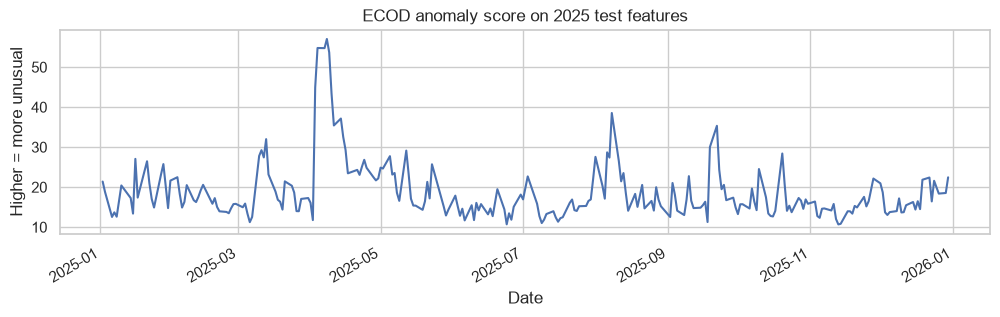

In [8]:
anomaly_imputer = SimpleImputer(strategy='median')
X_train_clean = anomaly_imputer.fit_transform(X_train)
X_valid_clean = anomaly_imputer.transform(X_valid)
X_test_clean = anomaly_imputer.transform(X_test)
ecod = ECOD(contamination=0.02).fit(X_train_clean)
valid_scores = ecod.decision_function(X_valid_clean)
test_scores = ecod.decision_function(X_test_clean)
test_flags = ecod.predict(X_test_clean)
anomaly_days = pd.DataFrame({'anomaly_score': test_scores, 'is_anomaly': test_flags.astype(bool)}, index=X_test.index).join(data[['target', 'return_1d', 'volatility_20', 'volume_change', 'high_low_range']]).join(raw[['Open', 'High', 'Low', 'Close', 'Volume']])
print('Flagged', int(test_flags.sum()), 'of', len(test_flags), 'test observations as unusual.')
print('Only', int(test_flags.sum()), 'days were flagged; treat their next-day outcomes as descriptive, not conclusive.')
print('Next-session open-to-close up share among flagged observations:', anomaly_days.loc[anomaly_days['is_anomaly'], 'target'].mean())
display(anomaly_days.loc[anomaly_days['is_anomaly']].nlargest(10, 'anomaly_score'))
anomaly_days['anomaly_score'].plot(figsize=(12, 3), title='ECOD anomaly score on 2025 test features')
plt.ylabel('Higher = more unusual'); plt.show()

## 5.2 Scikit-learn and Statsmodels classifiers

Scikit-learn supplies the preprocessing pipelines and tree models. A compact Statsmodels Logit model adds coefficient estimates and standard errors for interpretation. Inference is descriptive: correlated market features and temporal dependence limit causal or conventional significance claims.

## 5.2 Baselines and traditional models

Accuracy is reported alongside balanced accuracy so the always-majority baseline cannot look strong simply by ignoring the minority class. The momentum rule provides a simple signal-based reference.

In [9]:
class MomentumRule:
    """Predict up when trailing five-session return is positive."""
    def fit(self, X, y): return self
    def predict_proba(self, X):
        p_up = (X['return_5d'].to_numpy() > 0).astype(float)
        return np.column_stack([1 - p_up, p_up])
    def predict(self, X): return (X['return_5d'].to_numpy() > 0).astype(int)

class StatsmodelsLogitClassifier:
    """Statsmodels Logit adapter with compact standardized features."""
    feature_subset = ['return_1d', 'return_5d', 'price_vs_ma20', 'volatility_20', 'volume_change', 'high_low_range']
    def fit(self, X, y):
        self.scaler = StandardScaler().fit(X[self.feature_subset])
        scaled = pd.DataFrame(self.scaler.transform(X[self.feature_subset]), columns=self.feature_subset, index=X.index)
        self.result = sm.Logit(y, sm.add_constant(scaled, has_constant='add')).fit(method='lbfgs', disp=False, maxiter=1000)
        return self
    def predict_proba(self, X):
        scaled = pd.DataFrame(self.scaler.transform(X[self.feature_subset]), columns=self.feature_subset, index=X.index)
        probability = self.result.predict(sm.add_constant(scaled, has_constant='add')).to_numpy()
        return np.column_stack([1 - probability, probability])
    def predict(self, X): return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

def build_models():
    return {
        'Majority baseline': DummyClassifier(strategy='most_frequent'),
        'Momentum rule': MomentumRule(),
        'Statsmodels Logit': StatsmodelsLogitClassifier(),
        'Logistic Regression': make_pipeline(SimpleImputer(strategy='median'), StandardScaler(), LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42)),
        'Decision Tree': make_pipeline(SimpleImputer(strategy='median'), DecisionTreeClassifier(max_depth=4, min_samples_leaf=20, class_weight='balanced', random_state=42)),
        'Random Forest': make_pipeline(SimpleImputer(strategy='median'), RandomForestClassifier(n_estimators=300, max_depth=6, min_samples_leaf=15, class_weight='balanced_subsample', random_state=42, n_jobs=-1)),
    }
models = build_models()
for model in models.values(): model.fit(X_train, y_train)

def evaluate(model, X, y, threshold=0.5):
    pred = (model.predict_proba(X)[:, 1] >= threshold).astype(int) if hasattr(model, 'predict_proba') else model.predict(X)
    result = {'accuracy': accuracy_score(y, pred), 'balanced_accuracy': balanced_accuracy_score(y, pred),
              'precision': precision_score(y, pred, zero_division=0), 'recall': recall_score(y, pred, zero_division=0),
              'f1': f1_score(y, pred, zero_division=0)}
    if hasattr(model, 'predict_proba') and y.nunique() == 2: result['roc_auc'] = roc_auc_score(y, model.predict_proba(X)[:, 1])
    return result
validation_results = pd.DataFrame({n: evaluate(m, X_valid, y_valid) for n,m in models.items()}).T
display(validation_results.sort_values('balanced_accuracy', ascending=False).round(3))

,accuracy,balanced_accuracy,precision,recall,f1,roc_auc
Decision Tree,0.537,0.513,0.585,0.670,0.625,0.532
Statsmodels Logit,0.569,0.502,0.576,0.948,0.717,0.453
Majority baseline,0.575,0.500,0.575,1.000,0.730,0.500
Momentum rule,0.499,0.482,0.560,0.597,0.578,0.482
Random Forest,0.477,0.475,0.551,0.490,0.518,0.466
Logistic Regression,0.445,0.446,0.520,0.441,0.477,0.446


In [10]:
logit_effects = pd.DataFrame({
    'coefficient_per_feature_sd': models['Statsmodels Logit'].result.params,
    'standard_error': models['Statsmodels Logit'].result.bse,
    'p_value': models['Statsmodels Logit'].result.pvalues,
}).drop(index='const').sort_values('p_value')
display(logit_effects.round(4))
print('Treat p-values as exploratory; they do not account for all time-series dependence or model selection.')

,coefficient_per_feature_sd,standard_error,p_value
return_1d,-0.1366,0.0511,0.0075
volatility_20,-0.0423,0.0553,0.4450
high_low_range,0.0440,0.0597,0.4608
return_5d,0.0389,0.0733,0.5956
price_vs_ma20,0.0135,0.0739,0.8555
volume_change,-0.0086,0.0485,0.8599


Treat p-values as exploratory; they do not account for all time-series dependence or model selection.


## 6. Walk-forward validation and decision selection

Four expanding-window folds each validate on roughly one trading year inside the training period. A one-row gap prevents adjacent next-session targets from crossing a fold boundary. Select the model by mean fold balanced accuracy, then choose its probability threshold on 2023–2024 validation only. The 2025 period is held back until final evaluation. Earlier project versions reported results on this same period, so treat the corrected scores as retrospective rather than as a pristine unseen test.

Per-fold balanced accuracy:


model,Decision Tree,Logistic Regression,Majority baseline,Momentum rule,Random Forest,Statsmodels Logit
fold,,,,,,
1,0.473,0.505,0.5,0.491,0.475,0.479
2,0.517,0.544,0.5,0.468,0.494,0.554
3,0.500,0.524,0.5,0.425,0.520,0.524
4,0.498,0.456,0.5,0.513,0.511,0.478


Mean expanding-window metrics:


,balanced_accuracy,roc_auc
model,,
Statsmodels Logit,0.509,0.514
Logistic Regression,0.507,0.513
Random Forest,0.500,0.512
Majority baseline,0.500,0.500
Decision Tree,0.497,0.487
Momentum rule,0.474,0.474


Selected model by walk-forward balanced accuracy: Statsmodels Logit
Threshold chosen on validation only: 0.585
Validation balanced accuracy: 0.507


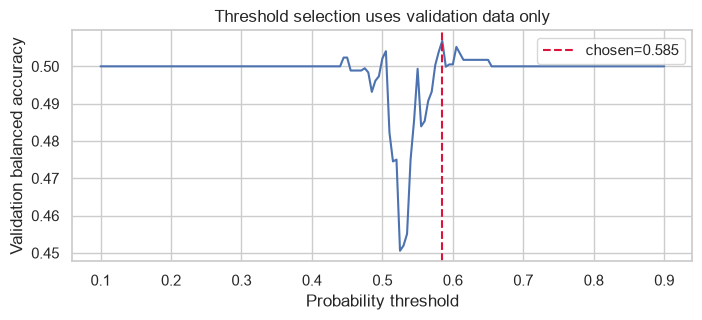

In [11]:
tscv = TimeSeriesSplit(n_splits=4, test_size=252, gap=1)
fold_rows = []
for fold, (fit_idx, score_idx) in enumerate(tscv.split(X_train), start=1):
    X_fit, y_fit = X_train.iloc[fit_idx], y_train.iloc[fit_idx]
    X_score, y_score = X_train.iloc[score_idx], y_train.iloc[score_idx]
    for name in models:
        fold_model = build_models()[name].fit(X_fit, y_fit)
        fold_rows.append({'fold': fold, 'model': name, **evaluate(fold_model, X_score, y_score)})
walk_forward = pd.DataFrame(fold_rows)
walk_forward_summary = walk_forward.groupby('model')[['balanced_accuracy', 'roc_auc']].mean().sort_values(['balanced_accuracy', 'roc_auc'], ascending=False)
print('Per-fold balanced accuracy:')
display(walk_forward.pivot(index='fold', columns='model', values='balanced_accuracy').round(3))
print('Mean expanding-window metrics:')
display(walk_forward_summary.round(3))
chosen_name = walk_forward_summary.index[0]
chosen_model = models[chosen_name]
valid_prob = chosen_model.predict_proba(X_valid)[:, 1]
threshold_rows = []
for threshold in np.linspace(0.10, 0.90, 161):
    pred = (valid_prob >= threshold).astype(int)
    threshold_rows.append({'threshold': threshold, 'balanced_accuracy': balanced_accuracy_score(y_valid, pred),
                           'f1': f1_score(y_valid, pred, zero_division=0)})
threshold_table = pd.DataFrame(threshold_rows)
threshold_table['distance_from_0_5'] = (threshold_table.threshold - 0.5).abs()
best = threshold_table.sort_values(['balanced_accuracy', 'distance_from_0_5'], ascending=[False, True]).iloc[0]
chosen_threshold = float(best.threshold)
print('Selected model by walk-forward balanced accuracy:', chosen_name)
print(f'Threshold chosen on validation only: {chosen_threshold:.3f}')
print(f'Validation balanced accuracy: {best.balanced_accuracy:.3f}')
plt.figure(figsize=(8,3)); plt.plot(threshold_table.threshold, threshold_table.balanced_accuracy)
plt.axvline(chosen_threshold, color='crimson', linestyle='--', label=f'chosen={chosen_threshold:.3f}')
plt.xlabel('Probability threshold'); plt.ylabel('Validation balanced accuracy')
plt.title('Threshold selection uses validation data only'); plt.legend(); plt.show()

## 6.1 Random Forest hyperparameter search

GridSearchCV compares a small, predeclared set of Random Forest depths and minimum leaf sizes using expanding-window folds from the training period only. It refits the best setting on all training data. The 2023–2024 validation period is used only to choose this challenger’s probability threshold; the 2025 period is held back from tuning and evaluated at the end. Earlier project versions reported results on this same period, so treat the corrected scores as retrospective rather than as a pristine unseen test. The search score is a tuning estimate, not an independent performance result. This tuned model is reported as a challenger and does not replace the existing walk-forward-selected model in the backtest.

In [12]:
rf_param_grid = {
    'randomforestclassifier__max_depth': [4, 6, 8],
    'randomforestclassifier__min_samples_leaf': [10, 15],
}
rf_search = GridSearchCV(
    estimator=build_models()['Random Forest'],
    param_grid=rf_param_grid,
    scoring='balanced_accuracy',
    cv=TimeSeriesSplit(n_splits=4, test_size=252, gap=1),
    n_jobs=1,
    refit=True,
    return_train_score=False,
)
rf_search.fit(X_train, y_train)
tuned_rf = rf_search.best_estimator_
print('Best training-fold parameters:', rf_search.best_params_)
print(f'Best mean training-fold balanced accuracy: {rf_search.best_score_:.3f}')
search_results = pd.DataFrame(rf_search.cv_results_)
display(search_results[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']]
        .sort_values(['rank_test_score', 'std_test_score']).round(3))

# Choose this challenger's classification threshold on validation only.
tuned_valid_prob = tuned_rf.predict_proba(X_valid)[:, 1]
tuned_threshold_rows = []
for threshold in np.linspace(0.10, 0.90, 161):
    tuned_pred = (tuned_valid_prob >= threshold).astype(int)
    tuned_threshold_rows.append({
        'threshold': threshold,
        'balanced_accuracy': balanced_accuracy_score(y_valid, tuned_pred),
        'f1': f1_score(y_valid, tuned_pred, zero_division=0),
    })
tuned_threshold_table = pd.DataFrame(tuned_threshold_rows)
tuned_threshold_table['distance_from_0_5'] = (tuned_threshold_table.threshold - 0.5).abs()
tuned_best = tuned_threshold_table.sort_values(
    ['balanced_accuracy', 'distance_from_0_5'], ascending=[False, True]
).iloc[0]
tuned_rf_threshold = float(tuned_best.threshold)
print(f'Tuned RF threshold selected on 2023–2024 validation: {tuned_rf_threshold:.3f}')
print(f'Tuned RF validation balanced accuracy: {tuned_best.balanced_accuracy:.3f}')


Best training-fold parameters: {'randomforestclassifier__max_depth': 6, 'randomforestclassifier__min_samples_leaf': 10}
Best mean training-fold balanced accuracy: 0.519


,params,mean_test_score,std_test_score,rank_test_score
2,"{'randomforestclassifier__max_depth': 6, 'rand...",0.519,0.017,1
0,"{'randomforestclassifier__max_depth': 4, 'rand...",0.509,0.027,2
5,"{'randomforestclassifier__max_depth': 8, 'rand...",0.505,0.023,3
1,"{'randomforestclassifier__max_depth': 4, 'rand...",0.503,0.021,4
4,"{'randomforestclassifier__max_depth': 8, 'rand...",0.502,0.026,5
3,"{'randomforestclassifier__max_depth': 6, 'rand...",0.500,0.017,6


Tuned RF threshold selected on 2023–2024 validation: 0.465
Tuned RF validation balanced accuracy: 0.513


## 7. Final test evaluation

The walk-forward-selected model and its threshold are frozen from training folds and 2023–2024 validation. The tuned Random Forest challenger is also evaluated once, using its settings selected from training-only folds and threshold selected on validation. Do not use 2025 test results to choose between them. The 2025 period was reported in earlier project versions, so this corrected evaluation is retrospective rather than a pristine unseen test.

,accuracy,balanced_accuracy,precision,recall,f1,roc_auc
Majority baseline,0.514,0.500,0.514,1.000,0.679,0.500
Momentum rule,0.522,0.522,0.535,0.539,0.537,0.522
Statsmodels Logit,0.478,0.467,0.495,0.844,0.624,0.432
Logistic Regression,0.458,0.459,0.468,0.406,0.435,0.441
Decision Tree,0.522,0.519,0.530,0.625,0.573,0.499
Random Forest,0.502,0.500,0.514,0.578,0.544,0.511
Statsmodels Logit (validation threshold),0.470,0.483,0.300,0.023,0.043,0.432
"Random Forest (grid search, threshold 0.50)",0.498,0.497,0.511,0.547,0.528,0.505
Tuned Random Forest (validation threshold),0.498,0.489,0.507,0.820,0.627,0.505


              precision    recall  f1-score   support

   Down/flat       0.48      0.94      0.63       121
          Up       0.30      0.02      0.04       128

    accuracy                           0.47       249
   macro avg       0.39      0.48      0.34       249
weighted avg       0.39      0.47      0.33       249



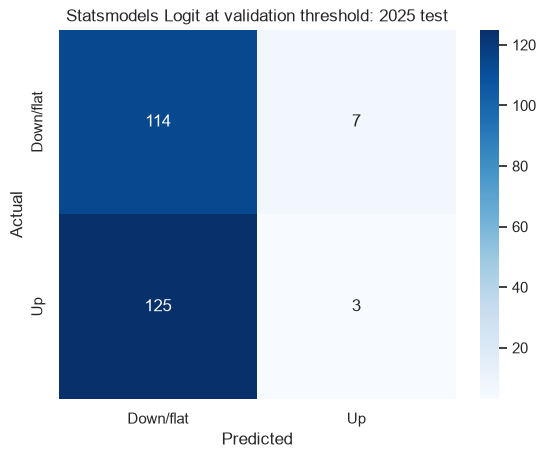

In [13]:
test_results = pd.DataFrame({n: evaluate(m, X_test, y_test) for n,m in models.items()}).T
selected_metrics = evaluate(chosen_model, X_test, y_test, threshold=chosen_threshold)
test_results.loc[f'{chosen_name} (validation threshold)'] = selected_metrics
test_results.loc['Random Forest (grid search, threshold 0.50)'] = evaluate(tuned_rf, X_test, y_test)
test_results.loc['Tuned Random Forest (validation threshold)'] = evaluate(
    tuned_rf, X_test, y_test, threshold=tuned_rf_threshold
)
display(test_results.round(3))
y_pred = (chosen_model.predict_proba(X_test)[:, 1] >= chosen_threshold).astype(int)
print(classification_report(y_test, y_pred, zero_division=0, target_names=['Down/flat','Up']))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=['Down/flat','Up'], yticklabels=['Down/flat','Up'])
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title(f'{chosen_name} at validation threshold: 2025 test'); plt.show()

## 8. Cost-aware execution proxy

Signals are formed after date t's close and acted on at the next session's open; positions exit at that session's close. The target and strategy both measure next-session open-to-close direction/returns. The signal is made after the prior close and entered at the next open. Costs assume 5 basis points per side (10 bps per daily round trip). Close-to-close buy-and-hold is shown as a reference with a different exposure window.

,total_return,annualized_volatility,max_drawdown
strategy,,,
"Statsmodels Logit long/cash, net of costs",4.0%,18.2%,-9.7%
"Always long open-to-close, net of costs",-0.7%,28.1%,-16.8%
Buy-and-hold close-to-close reference,11.9%,32.5%,-30.2%


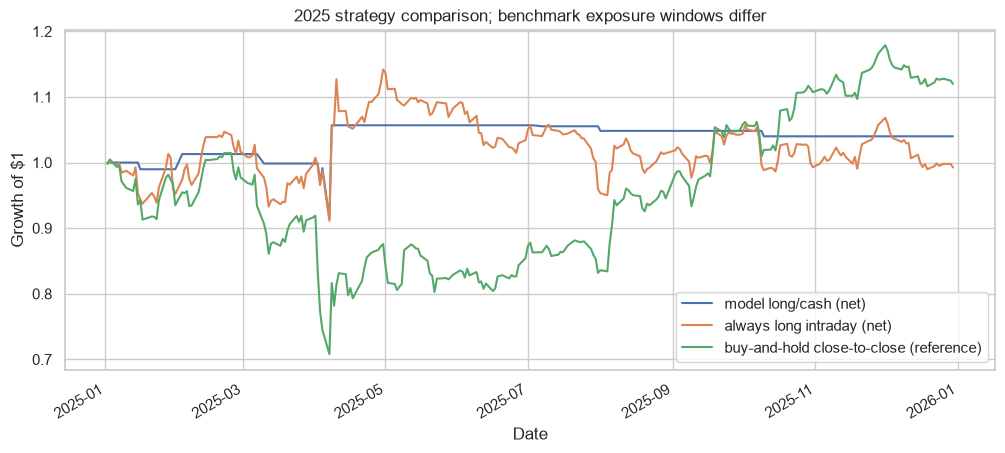

Buy-and-hold close-to-close is a reference; its exposure window differs from the daily intraday rules.


In [14]:
signals = pd.Series(y_pred, index=X_test.index)
next_open = raw['Open'].shift(-1).reindex(X_test.index)
next_close = raw['Close'].shift(-1).reindex(X_test.index)
open_to_close = next_close / next_open - 1
close_to_close = raw['Close'].shift(-1).reindex(X_test.index) / raw['Close'].reindex(X_test.index) - 1
fee_per_side = 0.0005
round_trip_cost = 2 * fee_per_side
strategy_net = signals * open_to_close - signals * round_trip_cost
intraday_long_net = open_to_close - round_trip_cost

def summarize_returns(name, returns):
    equity = (1 + returns).cumprod()
    drawdown = equity / equity.cummax() - 1
    return {'strategy': name, 'total_return': equity.iloc[-1] - 1,
            'annualized_volatility': returns.std(ddof=1) * np.sqrt(252), 'max_drawdown': drawdown.min()}
backtest_results = pd.DataFrame([
    summarize_returns(f'{chosen_name} long/cash, net of costs', strategy_net),
    summarize_returns('Always long open-to-close, net of costs', intraday_long_net),
    summarize_returns('Buy-and-hold close-to-close reference', close_to_close),
]).set_index('strategy')
backtest_results.loc['Buy-and-hold close-to-close reference','total_return'] = (1 + close_to_close).prod() * (1 - fee_per_side) ** 2 - 1
display(backtest_results.map(lambda x: f'{x:.1%}'))
equity = pd.DataFrame({'model long/cash (net)': (1+strategy_net).cumprod(),
                       'always long intraday (net)': (1+intraday_long_net).cumprod(),
                       'buy-and-hold close-to-close (reference)': (1+close_to_close).cumprod()}, index=X_test.index)
equity.plot(figsize=(12,5), title='2025 strategy comparison; benchmark exposure windows differ')
plt.ylabel('Growth of $1'); plt.show()
print('Buy-and-hold close-to-close is a reference; its exposure window differs from the daily intraday rules.')

## 9. Feature importance and findings

Interpret importances as model-specific associations, not causal effects. Record what validation and test results actually show; do not claim predictive value from an in-sample score.

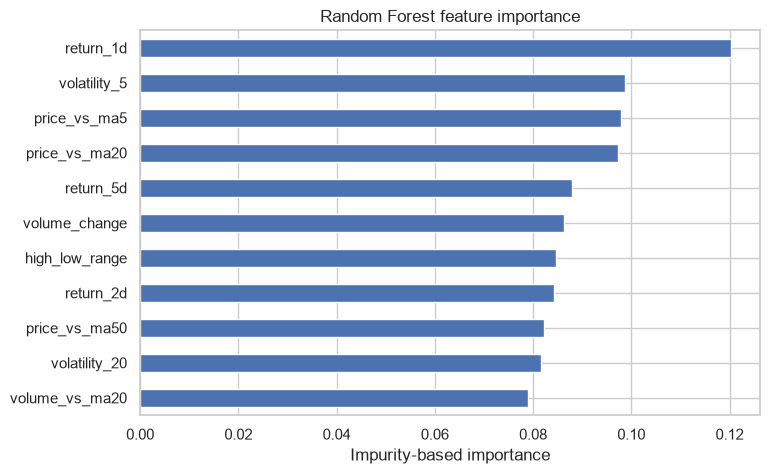

In [15]:
rf = models['Random Forest'].named_steps['randomforestclassifier']
importance = pd.Series(rf.feature_importances_, index=FEATURES).sort_values()
importance.plot.barh(figsize=(8, 5), title='Random Forest feature importance')
plt.xlabel('Impurity-based importance'); plt.show()

## Limitations and interpretation

- The next-session direction target and executable open-to-close backtest horizon differ; interpret the backtest as a costed proxy.
- Costs are fixed at 5 bps per side; actual slippage, taxes, market impact, and financing can be higher.
- Close-to-close buy-and-hold has a different exposure window from the daily intraday rules.
- Technical features only; no fundamentals, news, or macro variables.
- Model and threshold selection can still overfit training folds and validation years; use new future data for another honest check.